<a href="https://colab.research.google.com/github/esalramo94/TELECOM-X1/blob/main/REPORTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reporte de Análisis de Datos: Retención y Churn en TelecomX

Este notebook contiene el análisis de la cartera de clientes de TelecomX, incluyendo limpieza de datos, visualización y el reporte ejecutivo de hallazgos.

## 1. Resumen Ejecutivo
Tras procesar **7,043 registros**, identificamos que el **26.5% de los clientes han abandonado el servicio**. Los factores financieros (cargos mensuales altos) y contractuales (mes a mes) son los principales predictores de la fuga.

## 2. Hallazgos Clave
* **Costo:** El costo diario promedio es de **$2.16**. Los clientes que se van suelen pagar más que el promedio.
* **Contrato:** El contrato 'Month-to-month' es el de mayor riesgo.
* **Fidelización:** A mayor número de servicios adicionales (Seguridad, Backup, etc.), menor es la probabilidad de abandono.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
print('Librerías cargadas.')

Librerías cargadas.


In [2]:
url_api = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
df_raw = pd.read_json(url_api)

# Aplanamiento de datos
for col in ['customer', 'phone', 'internet', 'account']:
    df_expandido = df_raw[col].apply(pd.Series)
    df_raw = pd.concat([df_raw, df_expandido], axis=1)
    df_raw = df_raw.drop(col, axis=1)

# Limpieza de Churn
df = df_raw[df_raw['Churn'].isin(['Yes', 'No'])].copy()

# Procesamiento de Cargos
df_charges = df['Charges'].apply(pd.Series)
df = pd.concat([df, df_charges], axis=1)
df = df.drop('Charges', axis=1)

# Conversión a numérico
df['Monthly'] = pd.to_numeric(df['Monthly'], errors='coerce')
df['Cuentas_Diarias'] = (df['Monthly'] / 30).round(2)

print(f'Procesamiento completado. Registros finales: {len(df)}')

Procesamiento completado. Registros finales: 7043


### Visualización de Resultados

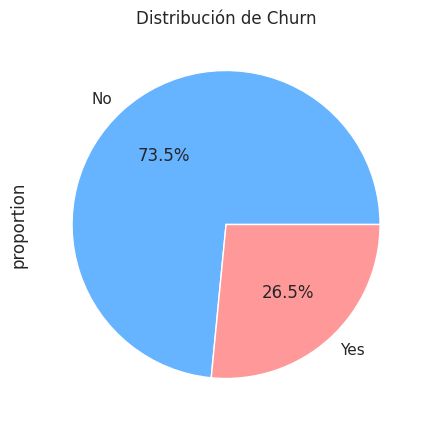

In [3]:
plt.figure(figsize=(8, 5))
df['Churn'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Distribución de Churn')
plt.show()

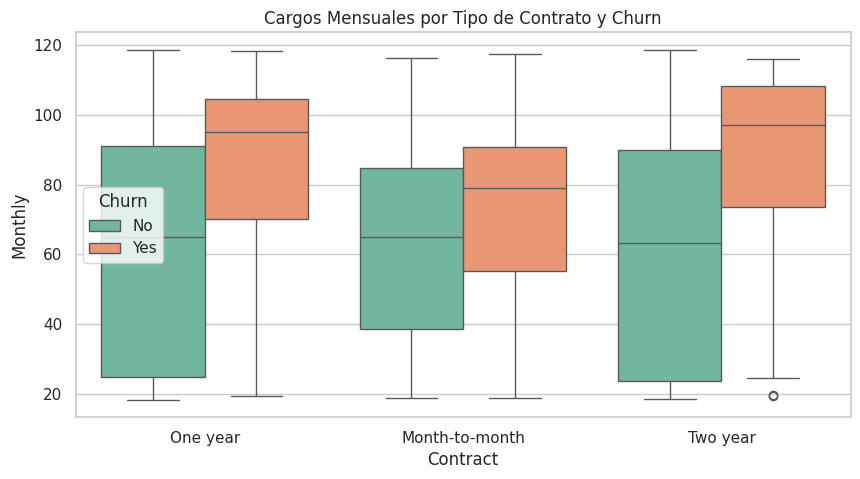

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Contract', y='Monthly', hue='Churn', data=df, palette='Set2')
plt.title('Cargos Mensuales por Tipo de Contrato y Churn')
plt.show()